> **Versão pública.** Este notebook rodou no Google Colab, com os dados e artefatos numa pasta do Google Drive do grupo. Para reproduzir, veja [Como reproduzir](../README.md#como-reproduzir).

# Imports e Configuração de Ambiente

In [1]:
path_notebook = '/content/drive/My Drive/<PASTA_DO_PROJETO>/Notebooks_Alexandre/03-Baseline/'

In [2]:
from google.colab import drive

import os
import sys

import pandas as pd
import numpy as np
from PIL import Image, ImageOps

import matplotlib.pyplot as plt
import seaborn as sns

import joblib
import gc

import tensorflow as tf

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.utils.class_weight import compute_class_weight

from sklearn import metrics

import matplotlib.cm as cm
from matplotlib.colors import ListedColormap

import random

In [3]:
drive.mount('/content/drive', force_remount = True)
#drive.flush_and_unmount()

Mounted at /content/drive


# Acessando API do Kaggle, Download e Extração do Dataset

In [4]:
#Instala a API
!pip install kaggle

In [5]:
# Move minhas credenciais para a pasta em que a API foi instalada
!mkdir -p ~/.kaggle/ && cp -i /content/drive/My Drive/<PASTA_DO_PROJETO>/kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json

In [6]:
#Baixa dos dados do Projeto, descompacta e deleta arquivo zip
!kaggle datasets download --force -d paultimothymooney/kermany2018 && unzip kermany2018.zip && rm kermany2018.zip

A saída de streaming foi truncada nas últimas 5000 linhas.
  inflating: oct2017/__MACOSX/OCT2017 /train/NORMAL/._NORMAL-8050636-2.jpeg  
  inflating: oct2017/__MACOSX/OCT2017 /train/NORMAL/._NORMAL-8055145-1.jpeg  
  inflating: oct2017/__MACOSX/OCT2017 /train/NORMAL/._NORMAL-8055145-2.jpeg  
  inflating: oct2017/__MACOSX/OCT2017 /train/NORMAL/._NORMAL-8055145-3.jpeg  
  inflating: oct2017/__MACOSX/OCT2017 /train/NORMAL/._NORMAL-8055590-1.jpeg  
  inflating: oct2017/__MACOSX/OCT2017 /train/NORMAL/._NORMAL-8055590-2.jpeg  
  inflating: oct2017/__MACOSX/OCT2017 /train/NORMAL/._NORMAL-8055590-3.jpeg  
[... 4985 linhas omitidas na versão pública ...]
  inflating: oct2017/__MACOSX/OCT2017 /val/NORMAL/._NORMAL-4872585-1.jpeg  
  inflating: oct2017/__MACOSX/OCT2017 /val/NORMAL/._NORMAL-5156112-1.jpeg  
  inflating: oct2017/__MACOSX/OCT2017 /val/NORMAL/._NORMAL-5171640-1.jpeg  
  inflating: oct2017/__MACOSX/OCT2017 /val/NORMAL/._NORMAL-5193994-1.jpeg  
  inflating: oct2017/__MACOSX/OCT2017 /val

# Visualização dos Dados

In [7]:
!ls /content/OCT2017\ /train/NORMAL | head -5

NORMAL-1001666-1.jpeg
NORMAL-1001772-1.jpeg
NORMAL-1001772-2.jpeg
NORMAL-1001772-3.jpeg
NORMAL-1001772-4.jpeg


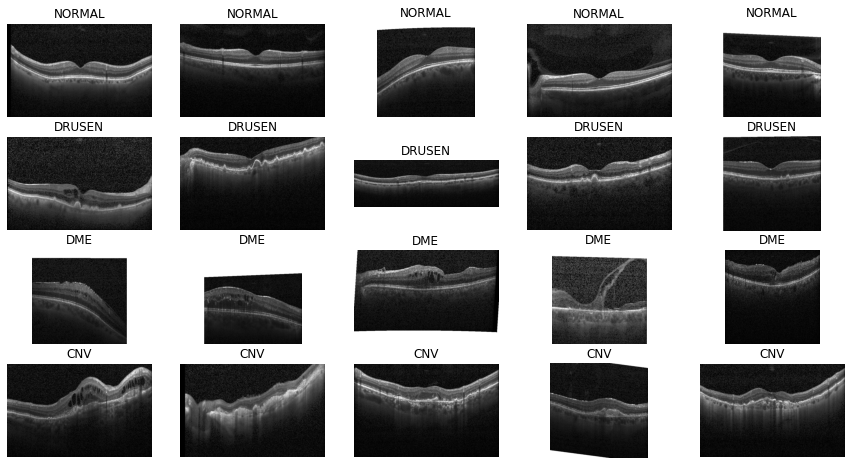

In [8]:
labels_folders = ['NORMAL', 'DRUSEN', 'DME', 'CNV']
num_img = 5

fig, ax = plt.subplots(len(labels_folders), num_img, figsize = (int(3*num_img), 2*len(labels_folders)))
for j in range(0, len(labels_folders)):
  label = labels_folders[j]
  path = '/content/OCT2017 /train/' + label + '/'
  lista_imagens = [f for f in os.listdir(path) if os.path.isfile(os.path.join(path, f))]
  for i in range(0, num_img):
      img_matrix = np.matrix(Image.open(path + lista_imagens[i]))
      ax[j][i].imshow(img_matrix, cmap='gray', vmin = 0, vmax = 255)
      ax[j][i].set_title(label)
      ax[j][i].set_axis_off()
plt.show()

# Analise do Dataset

In [9]:
#Cria datafame com as informações dos arquivos do dataset (não precisa rodar de novo - salvo em CSV)

#list_splits = ['train', 'val', 'test']
#labels_folders = ['NORMAL', 'DRUSEN', 'DME', 'CNV']

#df = pd.DataFrame(columns = ['Conjunto', 'Label_Pasta', 'Label_Arquivo', 'ID_Paciente', 'Num_Imagem'])

#for k in range(0, len(list_splits)):
#  conjunto = list_splits[k]
#  for j in range(0, len(labels_folders)):
#    label_pasta = labels_folders[j]
#    path = '/content/OCT2017 /' + conjunto + '/' + label_pasta + '/'
#    lista_imagens = [f for f in os.listdir(path) if os.path.isfile(os.path.join(path, f))]
#    for i in range(0, len(lista_imagens)):
#        df.loc[len(df)] = np.append([conjunto, label_pasta], lista_imagens[i][:-5].split('-'))

#df.to_csv(path_notebook + 'dataset_imagens.csv', index = False)
#display(df)

In [10]:
df = pd.read_csv(path_notebook + 'dataset_imagens.csv')

In [11]:
#Função Auxiliar para criar o caminho da imagem com base das informações do dataframe
def cria_path_img(linha):
  path = linha['Conjunto'] + '/' + linha['Label_Pasta'] + '/' + linha['Label_Arquivo'] + '-' + str(linha['ID_Paciente']) + '-' + str(linha['Num_Imagem']) + '.jpeg'
  return path

classes = ['CNV','DME','DRUSEN', 'NORMAL']

#Função para definir o padrão do nosso One Hot Enconder
def one_hot_encoder(y):
  if(y == 'CNV'):
    return [1, 0, 0, 0]
  elif(y == 'DME'):
    return [0, 1, 0, 0]
  elif(y == 'DRUSEN'):
    return [0, 0, 1, 0]
  elif(y == 'NORMAL'):
    return [0, 0, 0, 1]

#Função para inverter o One Hot Encoder
def inverse_one_hot_encoder_labels(y):
  if(np.argmax(y) == 0):
    return 'CNV'
  elif(np.argmax(y) == 1):
    return 'DME'
  elif(np.argmax(y) == 2):
    return 'DRUSEN'
  elif(np.argmax(y) == 3):
    return 'NORMAL'

#Converte a posição do vetor de One Hot Encoder no Label que ele representa
def numeric_to_string(y):
  if(y == 0):
    return 'CNV'
  elif(y == 1):
    return 'DME'
  elif(y == 2):
    return 'DRUSEN'
  elif(y == 3):
    return 'NORMAL'

In [12]:
#Checa a quantidade de imagens (tem 84484 e não 84495 como diz o kaggle!!)
print(len(df))

84484


In [13]:
#Checa se tem Labels incoerentes entre o nome da pasta e o nome do arquivo (Não tem!!)
print(np.sum(df['Label_Pasta'] != df['Label_Arquivo']))

0


In [14]:
#Agrupamento para analisar o dataset por paciente
def f(x):
  d = {}
  d['QTD_Arquivos_Imgs'] = len(x)
  d['QTD_Num_Imagens'] = len(x['Num_Imagem'].unique())
  d['QTD_train'] = np.sum(x['Conjunto'] == 'train')
  d['QTD_val'] = np.sum(x['Conjunto'] == 'val')
  d['QTD_test'] = np.sum(x['Conjunto'] == 'test')
  d['QTD_NORMAL'] = np.sum(x['Label_Arquivo'] == 'NORMAL')
  d['QTD_DME'] = np.sum(x['Label_Arquivo'] == 'DME')
  d['QTD_DRUSEN'] = np.sum(x['Label_Arquivo'] == 'DRUSEN')
  d['QTD_CNV'] = np.sum(x['Label_Arquivo'] == 'CNV')
  return pd.Series(d)

df_agrup = df.groupby('ID_Paciente').apply(lambda x: f(x))

In [15]:
#Quantidade de ID_Paciente distintos
print(len(df_agrup))

4657


In [16]:
#Pacientes que mais tem arquivos de imagens
df_agrup.sort_values('QTD_Arquivos_Imgs', ascending = False)[:10]

QTD_Arquivos_Imgs  QTD_Num_Imagens  ...  QTD_DRUSEN  QTD_CNV
ID_Paciente                                      ...                     
1188386                    817              813  ...           0      817
6652117                    614              613  ...           0      614
6666538                    585              585  ...           0      585
172472                     470              459  ...           0      470
7907754                    469              469  ...           0      469
9374492                    459              459  ...           0      459
1699976                    444              396  ...           0      401
1112835                    407              382  ...          23      384
9642260                    382              315  ...          66      315
1997439                    377              230  ...         140      237

[10 rows x 9 columns]

In [17]:
#Paciente estranho (tem imagens com doenças distintas)
df[df['ID_Paciente'] == 1112835].groupby(['ID_Paciente', 'Num_Imagem']).apply(lambda x: f(x)).sort_values('QTD_Arquivos_Imgs', ascending = False)[:10]

QTD_Arquivos_Imgs  QTD_Num_Imagens  ...  QTD_DRUSEN  QTD_CNV
ID_Paciente Num_Imagem                                      ...                     
1112835     1                           4                1  ...           2        2
            2                           3                1  ...           1        2
            13                          2                1  ...           1        1
            21                          2                1  ...           1        1
            20                          2                1  ...           1        1
            19                          2                1  ...           1        1
            18                          2                1  ...           1        1
            17                          2                1  ...           1        1
            16                          2                1  ...           1        1
            15                          2                1  ...           1        1

[10 rows x 9 columns]

Conjunto  ...                                            Caminho
33296    train  ...  /content/OCT2017 /train/DRUSEN/DRUSEN-1112835-...
62133    train  ...     /content/OCT2017 /train/CNV/CNV-1112835-1.jpeg
83947     test  ...  /content/OCT2017 /test/DRUSEN/DRUSEN-1112835-1...
84354     test  ...      /content/OCT2017 /test/CNV/CNV-1112835-1.jpeg

[4 rows x 6 columns]

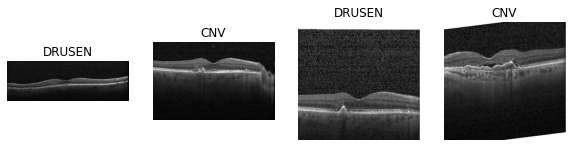

In [18]:
#Imagens estranhas do paciente estranho (duas imagens parecem do mesmo olho mas estão com anotações distintas)

df_imgs = df[(df['ID_Paciente'] == 1112835) & (df['Num_Imagem'] == 1)].copy()
path_raiz = '/content/OCT2017 /'
df_imgs['Caminho'] = df_imgs.apply(lambda x: path_raiz + cria_path_img(x), axis = 1)
display(df_imgs)

num_img = len(df_imgs)
fig, ax = plt.subplots(1, num_img, figsize = [10, 5])
for i in range(0, num_img):
  path = df_imgs.iloc[i]['Caminho']
  label = df_imgs.iloc[i]['Label_Arquivo']
  img_matrix = np.matrix(Image.open(path))
  ax[i].imshow(img_matrix, cmap='gray', vmin = 0, vmax = 255)
  ax[i].set_title(label)
  ax[i].set_axis_off()
plt.show()

In [19]:
#Pacientes "Honestos" no Teste
df_agrup[(df_agrup['QTD_train'] == 0) & (df_agrup['QTD_val'] == 0) & (df_agrup['QTD_test'] > 0)]

QTD_Arquivos_Imgs  QTD_Num_Imagens  ...  QTD_DRUSEN  QTD_CNV
ID_Paciente                                      ...                     
11053                        1                1  ...           0        0
70266                        3                3  ...           0        0
1102486                      4                4  ...           0        0
1274315                      2                2  ...           0        0
1430899                      1                1  ...           0        0
...                        ...              ...  ...         ...      ...
9109143                      1                1  ...           0        0
9211360                      2                2  ...           0        0
9241179                      1                1  ...           0        0
9378346                      3                3  ...           0        0
9488073                      2                2  ...           0        0

[63 rows x 9 columns]

# Refazendo a Distribuição dos Conjuntos (80/20 - Removendo Pacientes Intrusos)
#OBS: Mantendo Pacientes distintos em Treino/Validação e Estratificado

In [20]:
df_paths = df.copy()

In [21]:
#O conjunto de teste vai ficar o mesmo
#OBS: Os pacientes intrusos no treino ou na validação não serão colocados em um conjunto de Teste Complementar
#Tem 968 imagens no teste e não 1000 (o que aconteceu?)

df_paths['Novo_Conjunto'] = np.nan

df_paths.loc[df_paths['Conjunto'] == 'test', 'Novo_Conjunto'] = 'test'

#Lista de Pacientes que aparecem no Teste mas também aparecem no Treino ou na Validação
id_pacientes_intrusos = df_agrup[(df_agrup['QTD_test'] > 0) & ((df_agrup['QTD_train'] > 0) | (df_agrup['QTD_val'] > 0))].index.values

#Cria um conjunto de Teste Complementar
df_paths.loc[((df_paths['Conjunto'] == 'train') | (df_paths['Conjunto'] == 'val')) 
             & (df_paths['ID_Paciente'].isin(id_pacientes_intrusos)), 'Novo_Conjunto'] = 'test_compl'

print(len(df_paths[df_paths['Novo_Conjunto'] == 'test']))
print(len(df_paths[df_paths['Novo_Conjunto'] == 'test_compl']))

968
27693


In [22]:
#Separa o treino e validação entre o restante com 80/20 mantendo a mesma proporção das classes nos 2 conjuntos
#E garantindo pacientes distintos em cada conjunto

df_aux = df_paths[df_paths['Novo_Conjunto'].isna()]
prop_classes = dict(df_aux['Label_Arquivo'].value_counts(normalize = True))

#Agrupamento por paciente
def h(x):
  d = {}
  d['QTD_Arquivos'] = len(x)
  d['QTD_NORMAL'] = np.sum(x['Label_Arquivo'] == 'NORMAL')
  d['QTD_DME'] = np.sum(x['Label_Arquivo'] == 'DME')
  d['QTD_DRUSEN'] = np.sum(x['Label_Arquivo'] == 'DRUSEN')
  d['QTD_CNV'] = np.sum(x['Label_Arquivo'] == 'CNV')
  return pd.Series(d)

df_agrup_aux = df_aux.groupby('ID_Paciente').apply(lambda x: h(x)).reset_index()
df_agrup_aux = df_agrup_aux.sort_values('QTD_Arquivos').reset_index(drop = True)

In [23]:
#Encontra qual a classe que mais está longe da proporção esperada em um dataframe (de treino ou validação)
def classe_faltante(df, prop_classes, classes):
  tot = np.sum(df['QTD_Arquivos'])
  if(tot > 0):
    d = {'CNV': np.sum(df['QTD_CNV'])/tot,
        'DME': np.sum(df['QTD_DME'])/tot,
        'DRUSEN': np.sum(df['QTD_DRUSEN'])/tot,
        'NORMAL': np.sum(df['QTD_NORMAL'])/tot}
    classe_falt = classes[np.argmax([prop_classes[c] - d[c] for c in classes])]
    if(prop_classes[classe_falt] > d[classe_falt]):
      return classe_falt
    else:
      #Se não encontrar uma classe faltante, retorna a classe mais presente no dataset
      return classes[np.argmax([d[c] for c in classes])]
  else:
    #Se o dataset está vazio ainda, retorna a classe que queremos que seja a mais presente
    return classes[np.argmax([prop_classes[c] for c in classes])]

#Encontra o primeiro paciente que tem a classe desejada (no caso será a classe faltante a desejada)
def encontra_exemplo_classe(df_agrup_aux, indices, classe):
  df_temp = df_agrup_aux.loc[indices]
  i = 0
  qtd_classe = df_temp.iloc[0]['QTD_' + classe]
  while(i < len(df_temp)-1 and qtd_classe == 0):
    i = i + 1
    qtd_classe = df_temp.iloc[i]['QTD_' + classe]
  if(qtd_classe > 0):
    return i
  else:
    #OBS: Se não achar a classe desejada, retorna o primeiro paciente da lista
    return 0

#Define a fração que queremos dos dados na validação
frac_val = 0.2

#Algoritmo para distribuir os pacientes em treino e validação respeitando a fração escolhida
#E tentando manter a mesma proporção entre as classes do conjunto total
frac_train = 1 - frac_val
indices = list(df_agrup_aux.index)
df_train = pd.DataFrame(columns = df_agrup_aux.columns)
df_val = pd.DataFrame(columns = df_agrup_aux.columns)
for i in range(0, len(indices)):
  if(i == 0):
    df_train.loc[len(df_train)] = df_agrup_aux.loc[indices[i]]
    del indices[i]
  else:
    if(np.sum(df_train['QTD_Arquivos'])/frac_train > np.sum(df_val['QTD_Arquivos'])/frac_val):
      classe_ref = classe_faltante(df_val, prop_classes, classes)
      i_ref = encontra_exemplo_classe(df_agrup_aux, indices, classe_ref)
      df_val.loc[len(df_val)] = df_agrup_aux.iloc[indices[i_ref]]
      del indices[i_ref]
    else:
      classe_ref = classe_faltante(df_train, prop_classes, classes)
      i_ref = encontra_exemplo_classe(df_agrup_aux, indices, classe_ref)
      df_train.loc[len(df_train)] = df_agrup_aux.iloc[indices[i_ref]]
      del indices[i_ref]

In [24]:
pacientes_train = list(df_train['ID_Paciente'])
pacientes_val = list(df_val['ID_Paciente'])
df_paths.loc[df_paths['ID_Paciente'].isin(pacientes_train), 'Novo_Conjunto'] = 'train'
df_paths.loc[df_paths['ID_Paciente'].isin(pacientes_val), 'Novo_Conjunto'] = 'val'

display(df_paths[df_paths['Novo_Conjunto'] == 'train']['Label_Arquivo'].value_counts(normalize = True))
display(df_paths[df_paths['Novo_Conjunto'] == 'val']['Label_Arquivo'].value_counts(normalize = True))

NORMAL    0.410286
CNV       0.394852
DME       0.124188
DRUSEN    0.070673
Name: Label_Arquivo, dtype: float64

CNV       0.424023
NORMAL    0.390752
DME       0.121635
DRUSEN    0.063590
Name: Label_Arquivo, dtype: float64

In [25]:
#Distribuição de exemplos entre os novos conjuntos criados
df_paths['Novo_Conjunto'].value_counts()

train         44642
test_compl    27693
val           11181
test            968
Name: Novo_Conjunto, dtype: int64

In [26]:
#Distribuição das Classes nos Testes
display(df_paths[df_paths['Novo_Conjunto'] == 'test']['Label_Arquivo'].value_counts())
display(df_paths[(df_paths['Novo_Conjunto'] == 'test_compl')]['Label_Arquivo'].value_counts())

CNV       242
NORMAL    242
DRUSEN    242
DME       242
Name: Label_Arquivo, dtype: int64

CNV       14845
DRUSEN     4758
DME        4452
NORMAL     3638
Name: Label_Arquivo, dtype: int64

In [27]:
#Cria o caminho das imagens (path)
path_raiz = '/content/OCT2017 /'
df_paths['Caminho'] = df_paths.apply(lambda x: path_raiz + cria_path_img(x), axis = 1)

In [28]:
display(df_paths)

Conjunto  ...                                            Caminho
0        train  ...  /content/OCT2017 /train/NORMAL/NORMAL-5699128-...
1        train  ...  /content/OCT2017 /train/NORMAL/NORMAL-7641896-...
2        train  ...  /content/OCT2017 /train/NORMAL/NORMAL-8099138-...
3        train  ...  /content/OCT2017 /train/NORMAL/NORMAL-4055810-...
4        train  ...  /content/OCT2017 /train/NORMAL/NORMAL-3997725-...
...        ...  ...                                                ...
84479     test  ...      /content/OCT2017 /test/CNV/CNV-2959614-3.jpeg
84480     test  ...      /content/OCT2017 /test/CNV/CNV-1632795-1.jpeg
84481     test  ...      /content/OCT2017 /test/CNV/CNV-4244160-3.jpeg
84482     test  ...      /content/OCT2017 /test/CNV/CNV-1699976-1.jpeg
84483     test  ...      /content/OCT2017 /test/CNV/CNV-1415351-1.jpeg

[84484 rows x 7 columns]

# Análise dos Pacientes nos Novos Conjuntos

In [29]:
#Agrupamento para analisar o dataset por paciente após a nova distribuição dos conjuntos
def g(x):
  d = {}
  d['QTD_Arquivos_Imgs'] = len(x)
  d['QTD_Num_Imagens'] = len(x['Num_Imagem'].unique())
  d['QTD_train'] = np.sum(x['Novo_Conjunto'] == 'train')
  d['QTD_val'] = np.sum(x['Novo_Conjunto'] == 'val')
  d['QTD_test'] = np.sum(x['Novo_Conjunto'] == 'test')
  d['QTD_NORMAL'] = np.sum(x['Label_Arquivo'] == 'NORMAL')
  d['QTD_DME'] = np.sum(x['Label_Arquivo'] == 'DME')
  d['QTD_DRUSEN'] = np.sum(x['Label_Arquivo'] == 'DRUSEN')
  d['QTD_CNV'] = np.sum(x['Label_Arquivo'] == 'CNV')
  return pd.Series(d)

df_agrup_novo = df_paths.groupby('ID_Paciente').apply(lambda x: g(x))

In [30]:
#Checa se agora realmente não temos pacientes do teste em outros conjuntos (não tem)
df_agrup_novo[(df_agrup_novo['QTD_test'] > 0) & ((df_agrup_novo['QTD_train'] > 0) | (df_agrup_novo['QTD_val'] > 0))]

Empty DataFrame
Columns: [QTD_Arquivos_Imgs, QTD_Num_Imagens, QTD_train, QTD_val, QTD_test, QTD_NORMAL, QTD_DME, QTD_DRUSEN, QTD_CNV]
Index: []

In [31]:
#Checa agora se também o treino e a validação agora estão com pacientes distintos
display(df_agrup_novo[(df_agrup_novo['QTD_train'] > 0) & ((df_agrup_novo['QTD_test'] > 0) | (df_agrup_novo['QTD_val'] > 0))])
display(df_agrup_novo[(df_agrup_novo['QTD_val'] > 0) & ((df_agrup_novo['QTD_train'] > 0) | (df_agrup_novo['QTD_test'] > 0))])

Empty DataFrame
Columns: [QTD_Arquivos_Imgs, QTD_Num_Imagens, QTD_train, QTD_val, QTD_test, QTD_NORMAL, QTD_DME, QTD_DRUSEN, QTD_CNV]
Index: []

Empty DataFrame
Columns: [QTD_Arquivos_Imgs, QTD_Num_Imagens, QTD_train, QTD_val, QTD_test, QTD_NORMAL, QTD_DME, QTD_DRUSEN, QTD_CNV]
Index: []

In [32]:
df_paths = pd.read_csv(path_notebook + 'dataset_imagens_split.csv')

# Criação dos ImageGenerator Vanilla

In [33]:
def elimina_bordas_brancas(img_matrix):
  limiar = 0.001
  nivel_branco = 250
  altura = img_matrix.shape[0]
  largura = img_matrix.shape[1]
  linha_max = int(altura/2)
  coluna_max = int(largura/2)

  #Filtra a parte superior da imagem
  i = 0
  frac_branco = 1
  while(frac_branco > limiar and i < linha_max):
    flag_filtro = img_matrix[i, :] >= nivel_branco
    frac_branco = np.sum(flag_filtro)/len(flag_filtro)
    if(frac_branco >= limiar):
      img_matrix[i, np.where(flag_filtro)] = 0
    i = i + 1

  #Filtra a parte inferior da imagem
  i = 0
  frac_branco = 1
  while(frac_branco > limiar and i < linha_max):
    flag_filtro = img_matrix[altura-1-i, :] >= nivel_branco
    frac_branco = np.sum(flag_filtro)/len(flag_filtro)
    if(frac_branco >= limiar):
      img_matrix[altura-1-i, np.where(flag_filtro)] = 0
    i = i + 1

  #Filtra a parte esquerda da imagem
  i = 0
  frac_branco = 1
  while(frac_branco > limiar and i < coluna_max):
    flag_filtro = img_matrix[:, i] >= nivel_branco
    frac_branco = np.sum(flag_filtro)/len(flag_filtro)
    if(frac_branco >= limiar):
      img_matrix[np.where(flag_filtro), i] = 0
    i = i + 1

  #Filtra a parte direita da imagem
  i = 0
  frac_branco = 1
  while(frac_branco > limiar and i < coluna_max):
    flag_filtro = img_matrix[:, largura-1-i] >= nivel_branco
    frac_branco = np.sum(flag_filtro)/len(flag_filtro)
    if(frac_branco >= limiar):
      img_matrix[np.where(flag_filtro), largura-1-i] = 0
    i = i + 1

  return img_matrix

In [34]:
shape_reduzido = (299, 299)
batch_size = 32

datagen_vanilla = tf.keras.preprocessing.image.ImageDataGenerator(
    #preprocessing_function = elimina_bordas_brancas,
    rescale = 1.0/255.0,
    )

train_generator_vanilla = datagen_vanilla.flow_from_dataframe(
        df_paths[df_paths['Novo_Conjunto'] == 'train'], x_col = 'Caminho', y_col = 'Label_Arquivo',
        classes = classes,
        target_size = shape_reduzido,
        color_mode = 'grayscale',
        batch_size = batch_size,
        class_mode = 'categorical',
        #shuffle = False,
        )

valid_generator_vanilla = datagen_vanilla.flow_from_dataframe(
        df_paths[df_paths['Novo_Conjunto'] == 'val'], x_col = 'Caminho', y_col = 'Label_Arquivo',
        classes = classes,
        target_size = shape_reduzido,
        color_mode = 'grayscale',
        batch_size = batch_size,
        class_mode = 'categorical',
        #shuffle = False,
        )

print(train_generator_vanilla.class_indices)
print(valid_generator_vanilla.class_indices)

steps_train_vanilla = int(np.ceil(train_generator_vanilla.samples/batch_size))
steps_val_vanilla = int(np.ceil(valid_generator_vanilla.samples/batch_size))

print(steps_train_vanilla)
print(steps_val_vanilla)

Found 44642 validated image filenames belonging to 4 classes.
Found 11181 validated image filenames belonging to 4 classes.
{'CNV': 0, 'DME': 1, 'DRUSEN': 2, 'NORMAL': 3}
{'CNV': 0, 'DME': 1, 'DRUSEN': 2, 'NORMAL': 3}
1396
350


Conjunto de Treino:


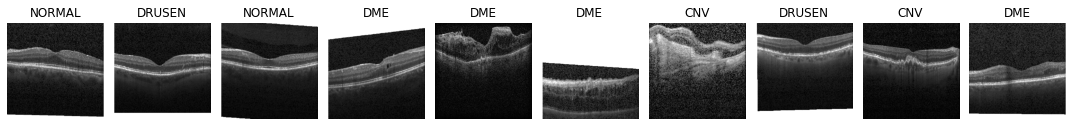

Conjunto de Validação:


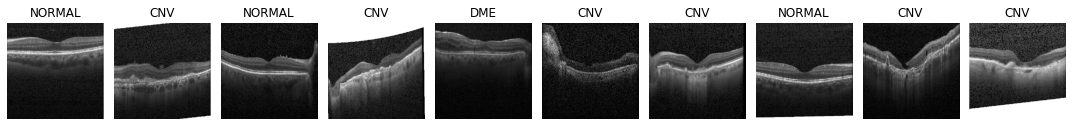

In [35]:
num_row = 1
num_col = 10
num = num_row*num_col

print('Conjunto de Treino:')
fig, axes = plt.subplots(num_row, num_col, figsize=(1.5*num_col,2*num_row))
exemplo_gen = next(train_generator_vanilla)
X = exemplo_gen[0]
y = exemplo_gen[1]
for i in range(num):
  ax = axes[i%num_col]
  ax.imshow(X[i, :, :, 0], cmap='gray', vmin = 0, vmax = 1)
  ax.set_title(inverse_one_hot_encoder_labels(y[i]))
  ax.set_axis_off()
plt.tight_layout()
plt.show()

print('Conjunto de Validação:')
fig, axes = plt.subplots(num_row, num_col, figsize=(1.5*num_col,2*num_row))
exemplo_gen = next(valid_generator_vanilla)
X = exemplo_gen[0]
y = exemplo_gen[1]
for i in range(num):
  ax = axes[i%num_col]
  ax.imshow(X[i, :, :, 0], cmap='gray', vmin = 0, vmax = 1)
  ax.set_title(inverse_one_hot_encoder_labels(y[i]))
  ax.set_axis_off()
plt.tight_layout()
plt.show()

Sem Tratamento:


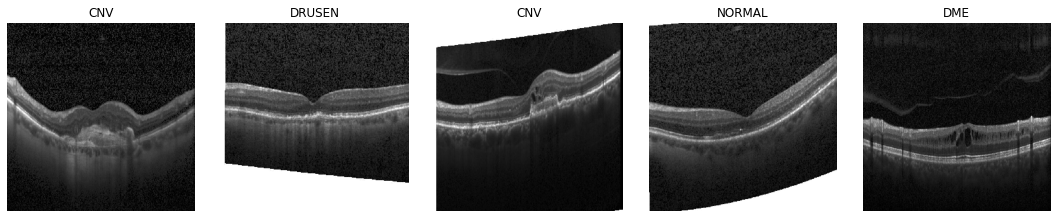

Com Tratamento:


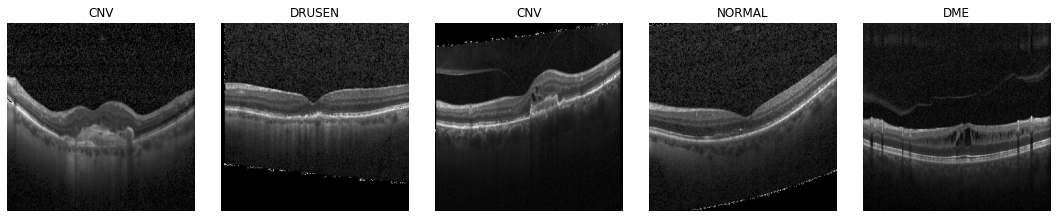

In [36]:
#Exemplo de Tratamento de Bordas
num_row = 1
num_col = 5
num = num_row*num_col

exemplo_gen = next(train_generator_vanilla)
X = exemplo_gen[0]
y = exemplo_gen[1]

print('Sem Tratamento:')
fig, axes = plt.subplots(num_row, num_col, figsize=(3*num_col,3*num_row))
for i in range(num):
  ax = axes[i%num_col]
  ax.imshow(X[i, :, :, 0], cmap='gray', vmin = 0, vmax = 1)
  ax.set_title(inverse_one_hot_encoder_labels(y[i]))
  ax.set_axis_off()
plt.tight_layout()
plt.show()

print('Com Tratamento:')
fig, axes = plt.subplots(num_row, num_col, figsize=(3*num_col,3*num_row))
for i in range(num):
  ax = axes[i%num_col]
  ax.imshow(elimina_bordas_brancas(X[i, :, :, 0]*255.0), cmap='gray', vmin = 0, vmax = 255)
  ax.set_title(inverse_one_hot_encoder_labels(y[i]))
  ax.set_axis_off()
plt.tight_layout()
plt.show()

#Extrator de Características:

In [37]:
loadnet = tf.keras.applications.Xception(input_shape = (shape_reduzido[0], shape_reduzido[1], 3), include_top = False, weights = 'imagenet')
loadnet.trainable = False

#Adiciona uma GlobalAveragePooling2D no final (redução das features extraídas)
featurenet = tf.keras.Sequential([loadnet, tf.keras.layers.GlobalAveragePooling2D()])
featurenet.summary()

#Guarda quantas features temos no final da rede
featurenet_output_shape = featurenet.layers[-1].get_output_shape_at(0)
shape_featurenet_flat = np.prod(featurenet_output_shape[1:])
print(shape_featurenet_flat)

83689472/83683744 [==============================] - 2s 0us/step
Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
xception (Functional)        (None, 10, 10, 2048)      20861480  
_________________________________________________________________
global_average_pooling2d (Gl (None, 2048)              0         
Total params: 20,861,480
Trainable params: 0
Non-trainable params: 20,861,480
_________________________________________________________________
2048


In [38]:
path_notebook = '/content/drive/My Drive/<PASTA_DO_PROJETO>/Notebooks_FelipeCesar/'

In [39]:
#Salva a arquitetura da rede e seus pesos
featurenet_json = featurenet.to_json()
with open(path_notebook + 'Xception.json', "w") as json_file:
    json_file.write(featurenet_json)
featurenet.save_weights(path_notebook + 'Xception.h5')

/usr/local/lib/python3.7/dist-packages/tensorflow/python/keras/utils/generic_utils.py:497: CustomMaskWarning: Custom mask layers require a config and must override get_config. When loading, the custom mask layer must be passed to the custom_objects argument.
  category=CustomMaskWarning)


In [41]:
#Carrega a arquitetura da rede e seus pesos
with open(path_notebook + 'Xception.json') as json_file:
  featurenet_json = json_file.read()
featurenet = tf.keras.models.model_from_json(featurenet_json)
featurenet.load_weights(path_notebook + 'Xception.h5')

In [42]:
#Exemplo de Extração de Features em um Batch do ImageGenerator

exemplo_gen = next(train_generator_vanilla)
X = exemplo_gen[0]
X = np.repeat(X[:, :, :, 0, np.newaxis], 3, -1) #Faz virar imagens de 3 canais
y = exemplo_gen[1]

featurenet.predict(X).reshape(batch_size, shape_featurenet_flat)

array([[6.04898691e-01, 2.32659057e-01, 9.80568366e-05, ...,
        1.10067604e-02, 8.33798125e-02, 0.00000000e+00],
       [3.80236626e-01, 1.22960202e-01, 2.54253857e-03, ...,
        2.64484952e-05, 4.05884832e-02, 0.00000000e+00],
       [2.07330629e-01, 3.07896227e-01, 1.67649239e-02, ...,
        5.49698528e-03, 4.31999564e-01, 0.00000000e+00],
       ...,
       [4.10340399e-01, 8.87307152e-02, 0.00000000e+00, ...,
        0.00000000e+00, 5.66549785e-02, 1.62086133e-02],
       [3.60740960e-01, 1.21392116e-01, 0.00000000e+00, ...,
        0.00000000e+00, 1.83197677e-01, 5.20577794e-03],
       [0.00000000e+00, 2.22237602e-01, 2.81833503e-02, ...,
        1.80545926e-01, 3.37309018e-02, 0.00000000e+00]], dtype=float32)

In [43]:
# Extração de Features direto dos arquivos das imagens
def extracao_features_baseline(df_paths, batch_size, featurenet):
  featurenet_output_shape = featurenet.layers[-1].get_output_shape_at(0)
  shape_featurenet_flat = np.prod(featurenet_output_shape[1:])
  
  x_conj = np.empty(shape = (0, shape_featurenet_flat))
  y_conj = np.array([])

  num_loop = int(np.ceil(len(df_paths)/batch_size))
  for i in range(0, num_loop):

    if(i < num_loop-1):
      paths = df_paths.iloc[i*batch_size:(i+1)*batch_size]['Caminho'].values
    else:
      paths = df_paths.iloc[i*batch_size:]['Caminho'].values

    batch = []
    for path in paths:
      #Carrega a Imagem e faz o preprocessamento (no caso é só reshape)
      X = np.array(Image.open(path).resize(shape_reduzido))/255.0 #como o reshape é quadrado, não precisamos inverter no reshape do PIL
      #OBS: lembrar que shapes de imagem são invertidos do shape de matrizes (linha, coluna) -> (coluna, linha)
      X = np.repeat(X[:, :, np.newaxis], 3, -1) #Faz virar imagens de 3 canais
      batch.append(X)
    batch = np.array(batch)

    x_conj = np.concatenate((x_conj, featurenet.predict(batch).reshape(len(batch), shape_featurenet_flat)), axis = 0)

    if(i < num_loop-1):
      y_conj = np.append(y_conj, df_paths.iloc[i*batch_size:(i+1)*batch_size]['Label_Arquivo'])
    else:
      y_conj = np.append(y_conj, df_paths.iloc[i*batch_size:]['Label_Arquivo'])

    del batch, X
    gc.collect()

  return x_conj, y_conj

In [44]:
#Define o batch de arquivos que vamos carregar por iteração
batch_size_iter = batch_size*(2**3)

In [45]:
#Lê os arquivos e faz a extração de características
#(Aqui terminamos com nosso conjunto de treino/validação com as features extraídas)

x_train, y_train = extracao_features_baseline(df_paths[df_paths['Novo_Conjunto'] == 'train'][['Caminho', 'Label_Arquivo']], 
                                              batch_size_iter, featurenet)
y_ohe_train = np.array([one_hot_encoder(y) for y in y_train])

x_val, y_val = extracao_features_baseline(df_paths[df_paths['Novo_Conjunto'] == 'val'][['Caminho', 'Label_Arquivo']], 
                                          batch_size_iter, featurenet)
y_ohe_val = np.array([one_hot_encoder(y) for y in y_val])

#Modelos Baseline: Rede Neural Fully-Connected

In [49]:
#Construção da rede fully-connected

input_shape = shape_featurenet_flat
output_shape = len(classes)

model_baseline_nn = tf.keras.models.Sequential()
model_baseline_nn.add(tf.keras.layers.Dense(output_shape, activation = 'softmax', input_shape=(input_shape,)))
model_baseline_nn.summary()

opt = tf.keras.optimizers.Adam(learning_rate = 0.001)
model_baseline_nn.compile(loss = 'categorical_crossentropy', optimizer = opt, metrics = ['accuracy'])

model_baseline_nn_json = model_baseline_nn.to_json()
with open(path_notebook + 'model_Xception.json', "w") as json_file:
    json_file.write(model_baseline_nn_json)

Model: "sequential_3"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_2 (Dense)              (None, 4)                 8196      
Total params: 8,196
Trainable params: 8,196
Non-trainable params: 0
_________________________________________________________________


In [50]:
#Calcula o pesos das classes para o treinamento
class_weights = compute_class_weight('balanced', classes, y_train)
train_class_weights = dict(enumerate(class_weights))
print(train_class_weights)

{0: 0.6331480115731548, 1: 2.0130772005772006, 2: 3.5374009508716324, 3: 0.6093306398777025}


In [51]:
means_train = np.mean(x_train, axis = 0)
stds_train = np.std(x_train, axis = 0)
joblib.dump([means_train, stds_train], path_notebook + 'normalizacao_Xception.pkl')

['/content/drive/My Drive/<PASTA_DO_PROJETO>/Notebooks_FelipeCesar/normalizacao_Xception.pkl']

In [52]:
means_train, stds_train = joblib.load(path_notebook + 'normalizacao_Xception.pkl')

In [53]:
#Treina a rede e salva os pesos obtidos para a melhor época do treinamento
#Salva também a curva de viés-variância do treinamento

model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath = path_notebook + 'weights_Xception.h5',
    save_weights_only = True,
    monitor = 'val_loss',
    mode = 'min',
    save_best_only = True,
    verbose = 1)

epochs = 50
H = model_baseline_nn.fit((x_train - means_train)/stds_train, y_ohe_train,
                          validation_data = ((x_val - means_train)/stds_train, y_ohe_val), 
                          class_weight = train_class_weights,
                          callbacks=[model_checkpoint_callback],
                          batch_size = batch_size, epochs = epochs, 
                          verbose = 1)

joblib.dump(H.history, path_notebook + 'history_Xception.pkl')
gc.collect()

Instructions for updating:
The `validate_indices` argument has no effect. Indices are always validated on CPU and never validated on GPU.
Epoch 1/50
1396/1396 [==============================] - 5s 3ms/step - loss: 0.6775 - accuracy: 0.7807 - val_loss: 0.5000 - val_accuracy: 0.8151

Epoch 00001: val_loss improved from inf to 0.49999, saving model to /content/drive/My Drive/<PASTA_DO_PROJETO>/Notebooks_FelipeCesar/weights_Xception.h5
Epoch 2/50
[... 187 linhas omitidas na versão pública ...]
Epoch 49/50
1396/1396 [==============================] - 4s 3ms/step - loss: 0.3742 - accuracy: 0.8761 - val_loss: 0.6820 - val_accuracy: 0.8298

Epoch 00049: val_loss did not improve from 0.48135
Epoch 50/50
1396/1396 [==============================] - 4s 3ms/step - loss: 0.3715 - accuracy: 0.8768 - val_loss: 0.6983 - val_accuracy: 0.8204

Epoch 00050: val_loss did not improve from 0.48135


2945

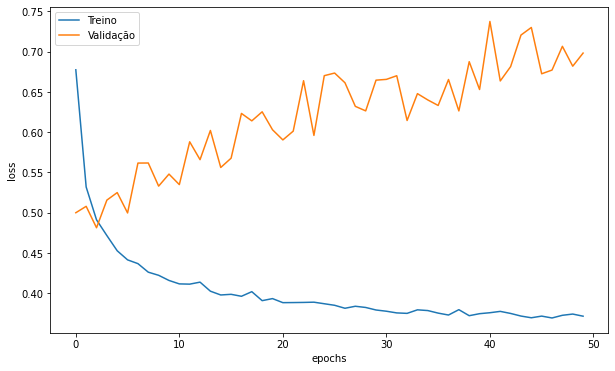

Loss Mínima: 0.4813464283943176
Época da Loss Mínima: 3


In [54]:
#Carrega os pesos da rede e a curva de viés-variância do treinamento
with open(path_notebook + 'model_Xception.json', 'r') as json_file:
  model_baseline_nn_json = json_file.read()
model_baseline_nn = tf.keras.models.model_from_json(model_baseline_nn_json)
model_baseline_nn.load_weights(path_notebook + 'weights_Xception.h5')
history = joblib.load(path_notebook + 'history_Xception.pkl')

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)                 
ax.plot(history['loss'], label = 'Treino')
ax.plot(history['val_loss'], label = 'Validação')
ax.set_xlabel('epochs')
ax.set_ylabel('loss')
ax.legend()
plt.show()

print('Loss Mínima: ' + str(np.min(history['val_loss'])))
print('Época da Loss Mínima: ' + str(1 + np.argmin(history['val_loss'])))

In [55]:
#Define a função de avaliação dos modelos em um conjunto (Calcula acurácia, acurácia balanceada e a matriz de confusão)
def evaluate(y, preds, labels = None, normalize = True):
    # Cálculo das métricas de acerto.
    print('Accuracy:', metrics.accuracy_score(y, preds).round(3))
    print('Accuracy (balanced):', metrics.balanced_accuracy_score(y, preds).round(3))
    
    # Calculo da matriz de confusão.
    r = metrics.confusion_matrix(y, preds)
    if(normalize):
      r = r / r.sum(axis = 1, keepdims = True)
    
    #Evita Erro quando um dos Labels não está presente no conjunto y avaliado ou na predição
    labels_x = [l for l in labels if l in list(np.unique(preds))]
    labels_y = [l for l in labels if l in list(np.unique(y))]
    if(len(labels_x) >= len(labels_y)):
      labels = labels_x
    else:
      labels = labels_y

    # Impressão dos gráficos.
    if(normalize):
      (plt
      .figure(figsize=(8, 6))
      .suptitle('Matriz de confusão', fontsize=20))
      sns.heatmap(r,
                  cmap = "YlGnBu", linewidths = .5, annot = True, fmt = ".1%",
                  xticklabels = labels, yticklabels = labels, cbar = False)
    else:
      (plt
      .figure(figsize=(8, 6))
      .suptitle('Matriz de confusão', fontsize=20))
      sns.heatmap(r,
                  cmap = "YlGnBu", linewidths = .5, annot = True, fmt = "",
                  xticklabels = labels, yticklabels = labels, cbar = False)
    plt.show()

Treino:
Accuracy: 0.852
Accuracy (balanced): 0.842


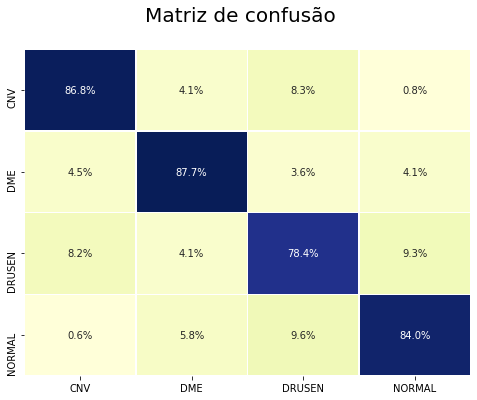

Validação:
Accuracy: 0.835
Accuracy (balanced): 0.761


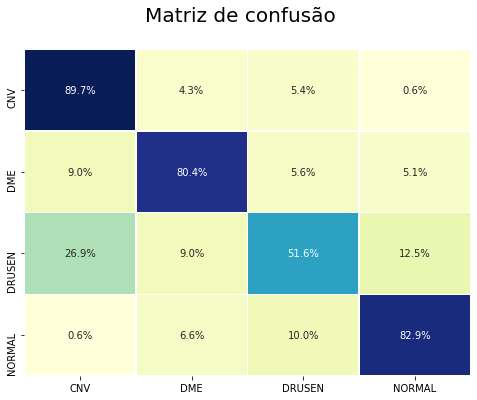

In [56]:
print('Treino:')
evaluate(y_train, np.array([numeric_to_string(np.argmax(p)) for p in model_baseline_nn.predict((x_train - means_train)/stds_train)]), labels = classes)

print('Validação:')
evaluate(y_val, np.array([numeric_to_string(np.argmax(p)) for p in model_baseline_nn.predict((x_val - means_train)/stds_train)]), labels = classes)

# Avaliação no Teste

In [57]:
#Extrai as features das imagens de teste

x_test, y_test = extracao_features_baseline(df_paths[df_paths['Novo_Conjunto'] == 'test'][['Caminho', 'Label_Arquivo']], 
                                          batch_size_iter, featurenet)
y_ohe_test = np.array([one_hot_encoder(y) for y in y_test])

x_test_compl, y_test_compl = extracao_features_baseline(df_paths[(df_paths['Novo_Conjunto'] == 'test_compl')][['Caminho', 'Label_Arquivo']], 
                                          batch_size_iter, featurenet)
y_ohe_test_compl = np.array([one_hot_encoder(y) for y in y_test_compl])

Teste (Fully-Connected-Xception):
Accuracy: 0.604
Accuracy (balanced): 0.604


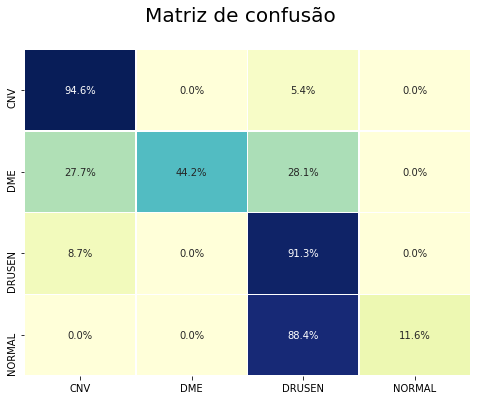

Teste Complementar (Fully-Connected-Xception):
Accuracy: 0.647
Accuracy (balanced): 0.511


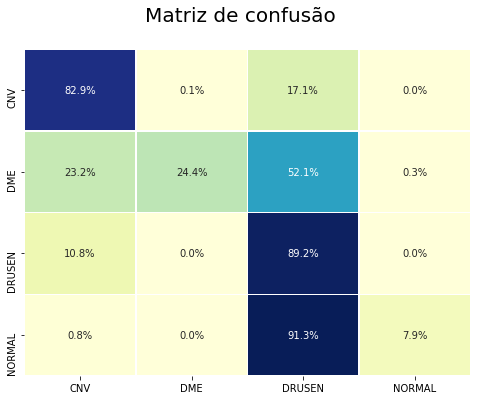

In [58]:
#Avalia a rede Fully-Connected no teste

print('Teste (Fully-Connected-Xception):')
evaluate(y_test, np.array([numeric_to_string(np.argmax(p)) for p in model_baseline_nn.predict(x_test)]), labels = classes)

print('Teste Complementar (Fully-Connected-Xception):')
evaluate(y_test_compl, np.array([numeric_to_string(np.argmax(p)) for p in model_baseline_nn.predict(x_test_compl)]), labels = classes)

# Interpretabilidade: Pertubation-CAM

In [59]:
class PerturbationCAM():

  #Passa a rede extratora de features, o modelo após a extração das features e o shape de input da rede inicial
  def __init__(self, featurenet, model, eh_nn = False, shape_input = (512, 512)):
    self.featurenet = featurenet
    self.model = model
    self.eh_nn = eh_nn
    self.shape_input = shape_input

  #Faz a predição de um batch de imagens (replica em 3 canais, extrai as features e faz o predict)
  #Note que se for uma rede neural o predict não é o mesmo método que um classificador com predict_proba
  def predict(self, batch_img):
    batch_img = np.repeat(batch_img[:, :, :, np.newaxis], 3, -1) #Faz virar imagens de 3 canais
    features_ref = self.featurenet.predict(batch_img)
    if(self.eh_nn):
      return self.model.predict(features_ref)
    else:
      return self.model.predict_proba(features_ref)

  #Faz a predição de uma só imagem e já retorna a classe predita em string
  def predict_label_one_img(self, img_array):
    batch_img = np.array([img_array])
    batch_img = np.repeat(batch_img[:, :, :, np.newaxis], 3, -1) #Faz virar imagens de 3 canais
    features_ref = self.featurenet.predict(batch_img)
    if(self.eh_nn):
      return numeric_to_string(np.argmax(self.model.predict(features_ref)[0]))
    else:
      return self.model.predict(features_ref)[0][0]
  
  #Faz os tratamentos necessários para a imagem de input 
  #(por enquanto só reescala para o shape da rede de extração de features e normaliza)
  def trata_imagem(self, img_array):
    return np.array(Image.fromarray(img_array).resize(self.shape_input[::-1]))/255.0

  #Recebe uma imagem só com um canal (preto e branco) normalizado entre 0 e 1
  #Retorna o mapa de calor para interpretabilidade
  def cria_mapa_calor(self, img_array, batch_cam = 32, num_random_mask = 10):
    shape_original = img_array.shape

    img_array = self.trata_imagem(img_array)

    #Faz uma predição da imagem sem alterações
    pred_ref = self.predict(np.array([img_array]))[0]

    #Faz um scan da imagem em conjunto de pixels dado pelo batch_cam
    i_max = int(img_array.shape[0]/batch_cam)
    j_max = int(img_array.shape[1]/batch_cam)
    perturbation_matrix = np.empty(shape = (i_max, j_max))
    for i in range(0, i_max):
      for j in range(0, j_max):
        #Para cada etapa do scan, alteramos os valores desses pixels da imagens nessa região num_random_mask vezes
        #E verificamos como essa alteração altera o valor predito
        img_temp = img_array.copy()
        batch = []
        for k in range(0, num_random_mask):
          img_temp[(batch_cam*i):(batch_cam*(i+1)), (batch_cam*j):(batch_cam*(j+1))] = np.random.rand(batch_cam, batch_cam)
          batch.append(img_temp)
        batch = np.array(batch)
        #Definimos a importância desse conjunto de pixels como a intensidade da perturbação média ocorrida na predição
        perturbation_matrix[i, j] = np.sum(np.sum((self.predict(batch) - pred_ref)**2, axis = 1)**0.5)/num_random_mask
    #Normaliza o valor das perturbações entre 0 e 1 (será nosso mapa de calor)
    perturbation_matrix = perturbation_matrix/np.max(perturbation_matrix)
    
    #Retornamos reescalando o mapa de calor para o shape da imagem original
    perturbation_matrix = np.array(Image.fromarray(perturbation_matrix).resize(shape_original[::-1]))
    return  np.where(perturbation_matrix < 0, 0, perturbation_matrix)

  def cria_mapa_calor_otimizado(self, img_array, batch_cam = 32, num_random_mask = 10, batch_predict = 2**7):
    shape_original = img_array.shape

    img_array = self.trata_imagem(img_array)

    #Faz uma predição da imagem sem alterações
    pred_ref = self.predict(np.array([img_array]))[0]

    trigger_predict = int(batch_predict/num_random_mask) #Trigger para sabe quando parar de acumular imagens na memória
    predicts = [] #Lista das predições feitas em batch
    count_predict = 0 #Contagem para saber quando atingimos o trigger de predição

    #Faz um scan da imagem em conjunto de pixels dado pelo batch_cam
    i_max = int(img_array.shape[0]/batch_cam)
    j_max = int(img_array.shape[1]/batch_cam)

    batch = []
    for i in range(0, i_max):
      for j in range(0, j_max):

        #Para cada etapa do scan, alteramos os valores desses pixels da imagens nessa região num_random_mask vezes
        #E verificamos como essa alteração altera o valor predito
        img_temp = img_array.copy()
        for k in range(0, num_random_mask):
          img_temp[(batch_cam*i):(batch_cam*(i+1)), (batch_cam*j):(batch_cam*(j+1))] = np.random.rand(batch_cam, batch_cam)
          batch.append(img_temp)

        #Checa se atingimos o trigger para fazer a predição do batch
        count_predict = count_predict + 1
        if(count_predict % trigger_predict == 0):
            batch = np.array(batch)
            predicts.append(self.predict(batch))
            batch = []
    #Faz a predição do último batch (o que sobrou após o loop acabar)
    if(len(batch) != 0):
      batch = np.array(batch)
      predicts.append(self.predict(batch))
      batch = []

    #Calcula a distância da predição de referência
    diff_preds = np.sum((np.concatenate(predicts) - pred_ref)**2, axis = 1)**0.5 
    
    #Calcula a média da distância da predição de referência para cada random de oclusão feito
    diff_preds = np.sum((np.concatenate(predicts) - pred_ref)**2, axis = 1)**0.5 
    diff_preds = np.mean(diff_preds.reshape(int(diff_preds.size/num_random_mask), num_random_mask), axis = 1)

    #Definimos a importância desse conjunto de pixels como a intensidade da perturbação média ocorrida na predição
    perturbation_matrix = diff_preds.reshape(i_max, j_max) #Recontrói o shape da matriz da imagem

    #Normaliza o valor das perturbações entre 0 e 1 (será nosso mapa de calor)
    perturbation_matrix = perturbation_matrix/np.max(perturbation_matrix)
    
    #Retornamos reescalando o mapa de calor para o shape da imagem original
    perturbation_matrix = np.array(Image.fromarray(perturbation_matrix).resize(shape_original[::-1]))
    return np.where(perturbation_matrix < 0, 0, perturbation_matrix)

In [60]:
#Dá cor para nosso mapa de calor
#Se use_heatmap_alpha = False retorna um mapa de calor que vai do azul para o vermelho
#Se use_heatmap_alpha = True retorna um mapa sempre vermelho mas com variação de alpha
def colorir_heatmap(img_heatmap, use_heatmap_alpha, alpha = 0.4):
    if(use_heatmap_alpha == False):
      jet = cm.get_cmap("jet") #Objeto para colorir o heatmap
      jet_colors = jet(np.arange(256))[:, :3]
      heatmap = np.uint8(255 * img_heatmap) # Reescala o heatmap entre 0 e 255 (inteiro)
      jet_heatmap = jet_colors[heatmap]

      #Define um alpha constante
      heatmap_alpha = img_heatmap
      jet_heatmap_nova = np.empty(shape = (img_heatmap.shape[0], img_heatmap.shape[1], 4))
      jet_heatmap_nova[:, :, :3] = jet_heatmap
      jet_heatmap_nova[:, :, 3] = alpha
      jet_heatmap = jet_heatmap_nova

    else:
      N = 256
      vals = np.ones((N, 4))
      vals[:, 0] = 1.0
      vals[:, 1] = 0.0
      vals[:, 2] = 0.0
      newcmp = ListedColormap(vals)
      jet_colors = newcmp(np.arange(256))[:, :3]
      heatmap = np.uint8(255 * img_heatmap) # Reescala o heatmap entre 0 e 255 (inteiro)
      jet_heatmap = jet_colors[heatmap]

      #Usa a própria intensidade da perturbação como alpha
      heatmap_alpha = img_heatmap*alpha
      jet_heatmap_nova = np.empty(shape = (img_heatmap.shape[0], img_heatmap.shape[1], 4))
      jet_heatmap_nova[:, :, :3] = jet_heatmap
      jet_heatmap_nova[:, :, 3] = heatmap_alpha
      jet_heatmap = jet_heatmap_nova

    return (jet_heatmap * 255).astype(np.uint8)

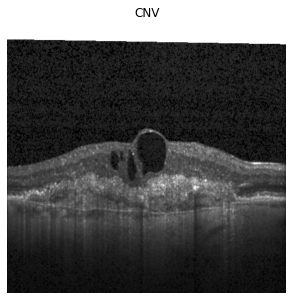

[0.48, 0.15, 0.25, 0.12]
CNV


In [61]:
#Escolhe a imagem de interesse pelo indice do dataset de imagens
ind_img = 84362

#Pega o caminho e o label da imagem
img_path = df_paths.iloc[ind_img]['Caminho']
label = df_paths.iloc[ind_img]['Label_Arquivo']

#Carrega a Imagem
img_array = np.array(Image.open(img_path))

#Plota a imagem de interesse
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.imshow(img_array, cmap = 'gray')
ax.set_title(label)
ax.set_axis_off()
plt.show()

#--Escolhe qual dos baseline vamos usar na predição e no CAM--

pert_cam = PerturbationCAM(featurenet, model_baseline_nn, eh_nn = True) 
#pert_cam = PerturbationCAM(featurenet, clf_cat, eh_nn = False) 

#-------------------------------------------------------------

probs = [float("%.2f" % p) for p in pert_cam.predict(np.array([pert_cam.trata_imagem(img_array)]))[0]]
predito = pert_cam.predict_label_one_img(pert_cam.trata_imagem(img_array))
print(probs)
print(predito)

In [62]:
#Calcula o mapa de calor
#img_heatmap = pert_cam.cria_mapa_calor(img_array, batch_cam = 32, num_random_mask = 10)
img_heatmap = pert_cam.cria_mapa_calor_otimizado(img_array, batch_cam = 32, num_random_mask = 10, batch_predict = 128)

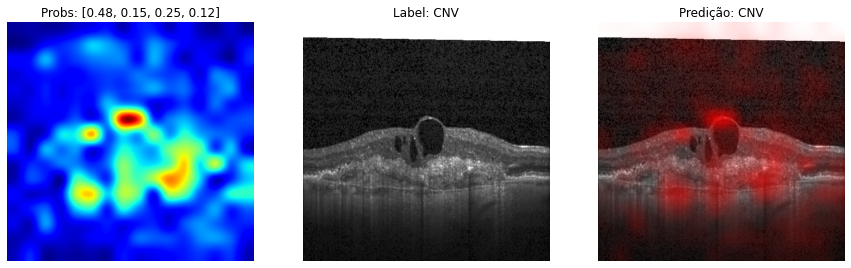

In [63]:
#Figura com:
# 1) Só o mapa de calor com as probabilidades do modelo
# 2) A imagem real com o label
# 3) A imagem com o mapa de calor sobreposto e o label predito pelo modelo

fig, ax = plt.subplots(1, 3, figsize=(15, 15))

ax[0].imshow(img_heatmap, cmap = cm.get_cmap("jet"))
ax[0].set_title('Probs: ' + str(probs))
ax[0].set_axis_off()

ax[1].imshow(img_array, cmap = 'gray')
ax[1].set_title('Label: ' + label)
ax[1].set_axis_off()

heatmap_colorido = colorir_heatmap(img_heatmap, use_heatmap_alpha = True, alpha = 0.75)
ax[2].imshow(img_array, cmap = 'gray')
ax[2].imshow(heatmap_colorido)
ax[2].set_title('Predição: ' + predito)
ax[2].set_axis_off()

plt.show()

# Mais Exemplos pq é legal!

In [64]:
num = 3
for c in range(0, len(classes)):
  if(c == 0):
    df_plot = df_paths[(df_paths['Novo_Conjunto'] == 'val')&(df_paths['Label_Arquivo'] == classes[c])].iloc[:num].copy()
  else:
    df_plot = pd.concat((df_plot, df_paths[(df_paths['Novo_Conjunto'] == 'val')&(df_paths['Label_Arquivo'] == classes[c])].iloc[:num].copy()))

In [65]:
pert_cam = PerturbationCAM(featurenet, model_baseline_nn, eh_nn = True) 
#pert_cam = PerturbationCAM(featurenet, clf_cat, eh_nn = False) 

for i in range(0, len(df_plot)):
  img_path = df_plot.iloc[i]['Caminho']
  label = df_plot.iloc[i]['Label_Arquivo']

  #Carrega a Imagem e faz o preprocessamento (no caso é só reshape)
  img_array = np.array(Image.open(img_path))

  probs = [float("%.2f" % p) for p in pert_cam.predict(np.array([pert_cam.trata_imagem(img_array)]))[0]]
  predito = pert_cam.predict_label_one_img(pert_cam.trata_imagem(img_array))

  img_heatmap = pert_cam.cria_mapa_calor(img_array, batch_cam = 32, num_random_mask = 10)

  fig, ax = plt.subplots(1, 3, figsize=(15, 15))

  ax[0].imshow(img_heatmap, cmap = cm.get_cmap("jet"))
  ax[0].set_title('Probs: ' + str(probs))
  ax[0].set_axis_off()
  ax[1].imshow(img_array, cmap = 'gray')
  ax[1].set_title('Label: ' + label)
  ax[1].set_axis_off()

  heatmap_colorido = colorir_heatmap(img_heatmap, use_heatmap_alpha = True, alpha = 0.75)
  ax[2].imshow(img_array, cmap = 'gray')
  ax[2].imshow(heatmap_colorido)
  ax[2].set_title('Predição: ' + predito)
  ax[2].set_axis_off()

  plt.show()

# Tutoriais Flask

In [ ]:
#https://towardsdatascience.com/create-and-deploy-a-simple-web-application-with-flask-and-heroku-103d867298eb
#https://github.com/damnever/pigar

In [ ]:
#https://www.retinadoctor.com.au/tests-consultation/optical-coherence-tomography-oct/
#https://www.retinadoctor.com.au/conditions/macular-oedema/

In [ ]:
#https://github.com/laurahanu/2D-and-3D-Deep-Autoencoder